# Custom YOLOv8 Fine-tuning + Integration
**Strategy:** Fine-tune `yolov8s.pt` (pretrained on COCO) on your 30-class Roboflow dataset.
- Uses `freeze=10` to preserve COCO backbone features → avoids catastrophic forgetting
- Heavy augmentation to compensate for 100 images/class
- Drop-in replacement for your existing `yolo_model` — zero changes to rest of pipeline


## Step 1 — Install Dependencies

In [1]:
!pip -q install ultralytics roboflow
print('✅ Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.6 MB/s eta 0:00:00
✅ Done


## Step 2 — Download Your Roboflow Dataset
Go to Roboflow → your project → Versions → Export → YOLOv8 format → Get Snippet.
Paste your API key, workspace, project name, and version below.

In [2]:
from roboflow import Roboflow

# ── FILL THESE IN ──────────────────────────────────────────────────────────────
ROBOFLOW_API_KEY  = "piRAU2OYmnMka0y1L34e"
WORKSPACE_NAME    = "jude-qudah"
PROJECT_NAME      = "echovision-lyq25"
VERSION_NUMBER    = 2
# ───────────────────────────────────────────────────────────────────────────────

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
dataset = project.version(VERSION_NUMBER).download("yolov8")

DATASET_PATH = dataset.location  # e.g. /content/your-project-1
DATA_YAML    = f"{DATASET_PATH}/data.yaml"

print(f"\n✅ Dataset downloaded to: {DATASET_PATH}")
print(f"   data.yaml: {DATA_YAML}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Echovision-2 in yolov8:: 100%|██████████| 12719/12719 [00:03<00:00, 3401.07it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

✅ Dataset downloaded to: /content/Echovision-2
   data.yaml: /content/Echovision-2/data.yaml


## Step 3 — Preview Your Dataset

In [3]:
import yaml, os

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print(f"Number of classes : {cfg['nc']}")
print(f"Class names       : {cfg['names']}")

# Count images per split
for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATASET_PATH, split, 'images')
    if os.path.exists(split_path):
        count = len(os.listdir(split_path))
        print(f"{split:6s} images: {count}")

Number of classes : 29
Class names       : ['AirConditioner', 'Cabinet', 'Charger', 'CoffeeMachine', 'Curtains', 'Dishwasher', 'Door', 'Drawer', 'Hairbrush', 'Hallway', 'Kettle', 'Keys', 'Menu', 'Mirror', 'Nightstand', 'Plate', 'PowerSocket', 'Shoe', 'SoapDispenser', 'Stairs', 'Switch', 'Table', 'TissueBox', 'Towel', 'Trashbin', 'Wallet', 'Wardrobe', 'WashingMachine', 'Window']
train  images: 5862
test   images: 247


In [4]:
import os
val_path = os.path.join(DATASET_PATH, 'valid', 'images')
print(os.path.exists(val_path))
print(len(os.listdir(val_path)) if os.path.exists(val_path) else "NOT FOUND")

True
245


## Step 4 — Fine-tune YOLOv8

Key settings explained:
- **`freeze=10`** — freezes the first 10 backbone layers so COCO knowledge is preserved
- **`epochs=80`** — enough for 100 img/class with augmentation
- **`mosaic=1.0`** — combines 4 images into 1 tile, hugely effective for small datasets
- **`mixup=0.1`** — blends pairs of images, improves generalization
- **`lr0=0.001`** — lower learning rate for fine-tuning (not training from scratch)

In [5]:
from ultralytics import YOLO

# Start from YOLOv8s pretrained on COCO — SAME model your pipeline already uses
model = YOLO("yolov8s.pt")

results = model.train(
    data       = DATA_YAML,
    epochs     = 80,
    imgsz      = 640,
    batch      = 16,          # reduce to 8 if you get OOM errors on T4
    device     = 0,            # GPU 0

    # ── Preserve COCO knowledge ──────────────────────────────────────────────
    freeze     = 10,           # freeze first 10 layers (backbone)
    lr0        = 0.001,        # fine-tuning LR (lower than default 0.01)
    lrf        = 0.01,         # final LR = lr0 * lrf

    # ── Augmentation (critical for 100 imgs/class) ───────────────────────────
    mosaic     = 1.0,          # mosaic augmentation (combines 4 images)
    mixup      = 0.1,          # mixup augmentation
    degrees    = 10.0,         # rotation
    translate  = 0.1,          # translation
    scale      = 0.5,          # scale jitter
    shear      = 2.0,          # shear
    fliplr     = 0.5,          # horizontal flip
    hsv_h      = 0.015,        # hue shift
    hsv_s      = 0.7,          # saturation
    hsv_v      = 0.4,          # brightness

    # ── Output ───────────────────────────────────────────────────────────────
    project = "/content/drive/MyDrive/yolo_results",
    name       = "run_v1",
    save_period= 10,           # save checkpoint every 10 epochs
    patience   = 20,           # early stopping if no improvement for 20 epochs
)

BEST_WEIGHTS = "custom_yolo_training/run_v1/weights/best.pt"
print(f"\n✅ Training complete! Best weights: {BEST_WEIGHTS}")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Echovision-2/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, 

## Step 5 — Evaluate the Model

In [16]:
from ultralytics import YOLO
import os

# Prioritize loading from the Google Drive path as specified by the 'project' argument in training.
PRIMARY_BEST_WEIGHTS = "/content/drive/MyDrive/yolo_results/run_v1/weights/best.pt"
FALLBACK_BEST_WEIGHTS = "/content/runs/detect/custom_yolo_training/run_v1/weights/best.pt"

weights_found = False
if os.path.exists(PRIMARY_BEST_WEIGHTS):
    BEST_WEIGHTS = PRIMARY_BEST_WEIGHTS
    print(f"Loading model from primary path (Google Drive): {BEST_WEIGHTS}")
    weights_found = True
elif os.path.exists(FALLBACK_BEST_WEIGHTS):
    BEST_WEIGHTS = FALLBACK_BEST_WEIGHTS
    print(f"Loading model from fallback path (/content/runs/detect): {BEST_WEIGHTS}")
    weights_found = True

if not weights_found:
    raise FileNotFoundError(
        f"Neither primary model path '{PRIMARY_BEST_WEIGHTS}' nor fallback path '{FALLBACK_BEST_WEIGHTS}' found."
    )

best_model = YOLO(BEST_WEIGHTS)
metrics = best_model.val(data=DATA_YAML, imgsz=640)

print(f"\n📊 Validation Results:")
print(f"   mAP50     : {metrics.box.map50:.3f}")
print(f"   mAP50-95  : {metrics.box.map:.3f}")
print(f"   Precision : {metrics.box.mp:.3f}")
print(f"   Recall    : {metrics.box.mr:.3f}")

# Per-class results
print("\nPer-class mAP50:")
for i, name in enumerate(best_model.names.values()):
    ap = metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0
    bar = '█' * int(ap * 20)
    print(f"  {name:25s} {ap:.2f}  {bar}")

Loading model from primary path (Google Drive): /content/drive/MyDrive/yolo_results/run_v1/weights/best.pt
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,136,807 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1603.5±488.3 MB/s, size: 51.7 KB)
val: Scanning /content/Echovision-2/valid/labels.cache... 245 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 245/245 102.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 5, len(boxes) = 361. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.4it/s 4.7s
                   all        245        361       0.83      0.815      0.865      0.577
        AirCondition

In [13]:
import os
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file == 'best.pt':
            print(os.path.join(root, file))

/content/drive/MyDrive/yolo_results/run_v1/weights/best.pt


In [18]:
import shutil
from google.colab import drive

# Use the path to the best weights that was successfully determined in the evaluation step.
# This should be the primary path in Google Drive where training results were saved.
BEST_WEIGHTS = "/content/drive/MyDrive/yolo_results/run_v1/weights/best.pt"

# Google Drive is likely already mounted from a previous cell, so this line is redundant and causes an error.
# drive.mount('/content/drive') # Removed this line

SAVE_PATH = "/content/drive/MyDrive/yolo_custom_best.pt"
shutil.copy(BEST_WEIGHTS, SAVE_PATH)
print(f"✅ Weights saved to Google Drive: {SAVE_PATH}")

✅ Weights saved to Google Drive: /content/drive/MyDrive/yolo_custom_best.pt


## Step 6 — Save Weights to Google Drive (Recommended)
So you don't lose them when Colab resets.

In [20]:
from google.colab import drive
import shutil

# Google Drive is likely already mounted from a previous cell, so this line is redundant.
# drive.mount('/content/drive')

# The BEST_WEIGHTS variable was determined in previous steps
# and refers to the trained model in Google Drive.
BEST_WEIGHTS = "/content/drive/MyDrive/yolo_results/run_v1/weights/best.pt"

SAVE_PATH = "/content/drive/MyDrive/yolo_custom_best.pt"
shutil.copy(BEST_WEIGHTS, SAVE_PATH)
print(f"✅ Weights saved to Google Drive: {SAVE_PATH}")

✅ Weights saved to Google Drive: /content/drive/MyDrive/yolo_custom_best.pt


---
# Integration Into Your Existing Pipeline
**Copy the cell below into your `Final_Describe_Fixed` notebook.**
It replaces the single line `yolo_model = YOLO("yolov8s.pt")`.
Everything else — `run_yolo()`, `build_scene_json()`, MiDaS, RelTR — stays exactly the same.

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# REPLACE YOUR EXISTING yolo_model LOADING CELL WITH THIS
# ═══════════════════════════════════════════════════════════════════════════════
from ultralytics import YOLO
import torch, os

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── Option A: Load from Google Drive (after you've saved it there) ───────────
CUSTOM_WEIGHTS_GDRIVE = "/content/drive/MyDrive/yolo_custom_best.pt"

# ── Option B: Load from local training output (same Colab session) ───────────
CUSTOM_WEIGHTS_LOCAL  = "custom_yolo_training/run_v1/weights/best.pt"

# ── Pick whichever path exists ────────────────────────────────────────────────
if os.path.exists(CUSTOM_WEIGHTS_GDRIVE):
    weights_path = CUSTOM_WEIGHTS_GDRIVE
    print("Loading custom weights from Google Drive...")
elif os.path.exists(CUSTOM_WEIGHTS_LOCAL):
    weights_path = CUSTOM_WEIGHTS_LOCAL
    print("Loading custom weights from local training...")
else:
    # Fallback to original COCO model if custom weights not found
    weights_path = "yolov8s.pt"
    print("⚠️  Custom weights not found — falling back to COCO yolov8s.pt")

yolo_model = YOLO(weights_path)
yolo_model.to(device)

print(f"\n✅ YOLOv8 loaded: {weights_path}")
print(f"   Classes ({len(yolo_model.names)}): {list(yolo_model.names.values())}")

Loading custom weights from Google Drive...

✅ YOLOv8 loaded: /content/drive/MyDrive/yolo_custom_best.pt
   Classes (29): ['AirConditioner', 'Cabinet', 'Charger', 'CoffeeMachine', 'Curtains', 'Dishwasher', 'Door', 'Drawer', 'Hairbrush', 'Hallway', 'Kettle', 'Keys', 'Menu', 'Mirror', 'Nightstand', 'Plate', 'PowerSocket', 'Shoe', 'SoapDispenser', 'Stairs', 'Switch', 'Table', 'TissueBox', 'Towel', 'Trashbin', 'Wallet', 'Wardrobe', 'WashingMachine', 'Window']


In [23]:
from ultralytics import YOLO
import torch, cv2, os, json, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

from google.colab import drive
# drive.mount('/content/drive') # Removed this redundant call

CUSTOM_WEIGHTS_GDRIVE = "/content/drive/MyDrive/yolo_custom_best.pt"

if os.path.exists(CUSTOM_WEIGHTS_GDRIVE):
    weights_path = CUSTOM_WEIGHTS_GDRIVE
    print("Loading custom weights from Google Drive...")
else:
    weights_path = "yolov8s.pt"
    print("⚠️ Custom weights not found — falling back to COCO yolov8s.pt")

yolo_model = YOLO(weights_path)
yolo_model.to(device)

print(f"\n✅ YOLOv8 loaded: {weights_path}")
print(f"   Classes ({len(yolo_model.names)}): {list(yolo_model.names.values())}")

Device: cuda
Loading custom weights from Google Drive...

✅ YOLOv8 loaded: /content/drive/MyDrive/yolo_custom_best.pt
   Classes (29): ['AirConditioner', 'Cabinet', 'Charger', 'CoffeeMachine', 'Curtains', 'Dishwasher', 'Door', 'Drawer', 'Hairbrush', 'Hallway', 'Kettle', 'Keys', 'Menu', 'Mirror', 'Nightstand', 'Plate', 'PowerSocket', 'Shoe', 'SoapDispenser', 'Stairs', 'Switch', 'Table', 'TissueBox', 'Towel', 'Trashbin', 'Wallet', 'Wardrobe', 'WashingMachine', 'Window']


Saving new-hairbrush-gettyimages-178554556-ffd0d62aa20444339f6d8a26b04938cf.jpg to new-hairbrush-gettyimages-178554556-ffd0d62aa20444339f6d8a26b04938cf (2).jpg
Uploaded: new-hairbrush-gettyimages-178554556-ffd0d62aa20444339f6d8a26b04938cf (2).jpg

image 1/1 /content/new-hairbrush-gettyimages-178554556-ffd0d62aa20444339f6d8a26b04938cf (2).jpg: 448x640 2 Hairbrushs, 48.5ms
Speed: 2.4ms preprocess, 48.5ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
Detected 2 object(s)
  Hairbrush            conf=0.77
  Hairbrush            conf=0.66


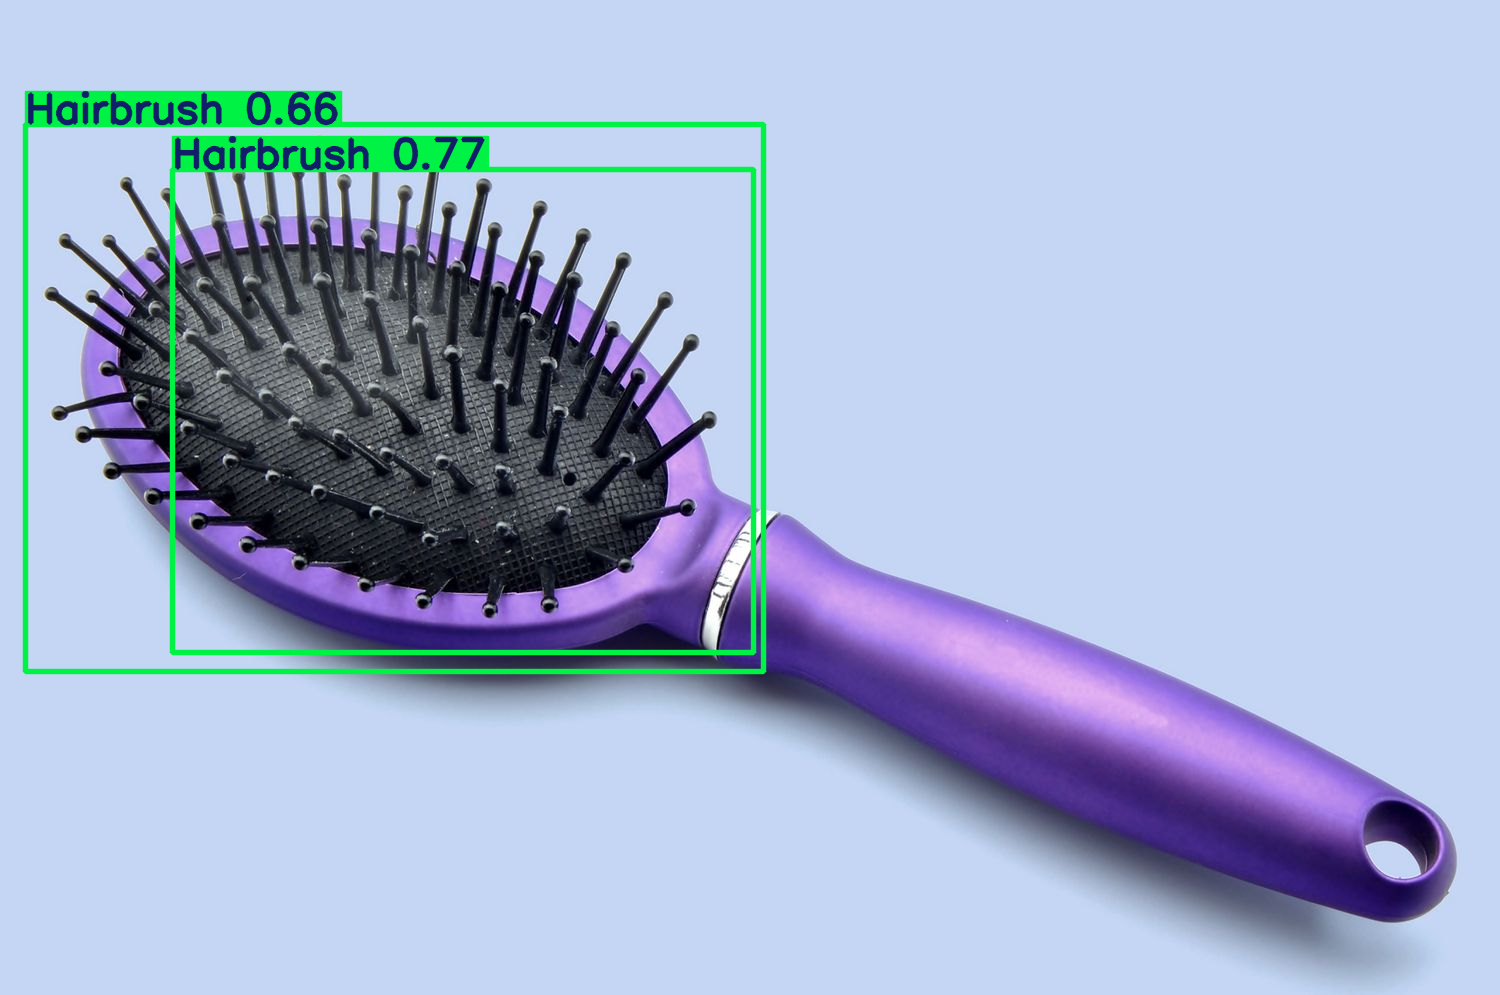

In [27]:
from google.colab import files
from IPython.display import display, Image as IPImage

# Upload an image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"Uploaded: {img_path}")

# Run inference
results = yolo_model(img_path)
dets = results[0].boxes
print(f"Detected {len(dets)} object(s)")
for box in dets:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    label = yolo_model.names[cls_id]
    print(f"  {label:20s} conf={conf:.2f}")

# Show the annotated result
results[0].show()

## Verify: run_yolo() works unchanged

---
## Troubleshooting

| Problem | Fix |
|---|---|
| `CUDA out of memory` during training | Set `batch=8` instead of `batch=16` |
| mAP < 40% after training | Your classes may need more images — aim for 200+ per class |
| Custom classes detected but COCO classes missing | Verify `freeze=10` was set, or try `freeze=5` |
| Roboflow download fails | Double-check API key and version number |
| `best.pt` not found | Training crashed early — check GPU memory, reduce batch size |